<a href="https://colab.research.google.com/github/Dheemant-12/CreditCardFraudDetection/blob/main/PrimeTradeAi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # upload both CSVs: sentiment + trader data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
%matplotlib inline

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [3]:
sentiment = pd.read_csv('fear_greed_index.csv')   # rename to your actual filename
trades = pd.read_csv('historical_data.csv')

print(sentiment.shape, trades.shape)
display(sentiment.head())
display(trades.head())
print(sentiment.dtypes)
print(trades.dtypes)

(2644, 4) (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


timestamp          int64
value              int64
classification    object
date              object
dtype: object
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [6]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment.drop_duplicates()
print(sentiment['classification'].unique())  # confirm categories (Fear/Greed/Extreme Fear etc.)

['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']


In [11]:
# 'Timestamp' column (epoch ms) is more reliable than 'Timestamp IST' string — use that
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
trades['date'] = trades['datetime'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# rename for easier handling
trades = trades.rename(columns={
    'Account':'account', 'Coin':'coin', 'Execution Price':'exec_price',
    'Size Tokens':'size_tokens', 'Size USD':'size_usd', 'Side':'side',
    'Start Position':'start_position', 'Direction':'direction',
    'Closed PnL':'closed_pnl', 'Fee':'fee'
})

trades = trades.dropna(subset=['closed_pnl', 'size_usd', 'side'])
trades = trades[trades['size_usd'] > 0]

print(trades.isnull().sum())
print(trades['side'].unique(), trades['direction'].unique())
print(trades['date'].min(), trades['date'].max())

account             0
coin                0
exec_price          0
size_tokens         0
size_usd            0
side                0
Timestamp IST       0
start_position      0
direction           0
closed_pnl          0
Transaction Hash    0
Order ID            0
Crossed             0
fee                 0
Trade ID            0
Timestamp           0
datetime            0
date                0
dtype: int64
['BUY' 'SELL'] ['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']
2023-03-28 00:00:00 2025-06-15 00:00:00


In [13]:
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())
print("Trade date range:", trades['date'].min(), "to", trades['date'].max())

overlap = set(trades['date'].unique()) & set(sentiment['date'].unique())
print(f"{len(overlap)} overlapping dates out of {trades['date'].nunique()} trade dates")

Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trade date range: 2023-03-28 00:00:00 to 2025-06-15 00:00:00
6 overlapping dates out of 7 trade dates


In [14]:
df = trades.merge(sentiment, on='date', how='left')
print(f"{df['classification'].isnull().sum()} trades with no sentiment match")
df = df.dropna(subset=['classification'])
print(df.shape)

26961 trades with no sentiment match
(184220, 21)


In [15]:
df['win'] = df['closed_pnl'] > 0
df['pnl_pct'] = df['closed_pnl'] / (df['exec_price'] * df['size_tokens'])
df['net_pnl'] = df['closed_pnl'] - df['fee']

daily_trader = df.groupby(['account','date','classification']).agg(
    total_pnl=('closed_pnl','sum'),
    net_pnl=('net_pnl','sum'),
    avg_pnl=('closed_pnl','mean'),
    win_rate=('win','mean'),
    trade_count=('closed_pnl','count'),
    avg_size_usd=('size_usd','mean'),
    total_fees=('fee','sum')
).reset_index()

display(daily_trader.head())

,account,date,classification,total_pnl,net_pnl,avg_pnl,win_rate,trade_count,avg_size_usd,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,Greed,-3.275059e+05,-3.286188e+05,-708.887230,0.025974,462,14810.891818,1112.895650
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,Fear,1.927736e+06,1.921443e+06,574.414696,0.405542,3356,16345.241940,6292.416654
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,Greed,2.060745e+04,2.040528e+04,64.398269,0.531250,320,2492.749906,202.167151
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,Fear,1.709873e+04,1.543381e+04,4.841089,0.435164,3532,1693.831116,1664.914670
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,Neutral,-1.000000e+00,-1.119793e+01,-0.200000,0.000000,5,6070.200000,10.197932


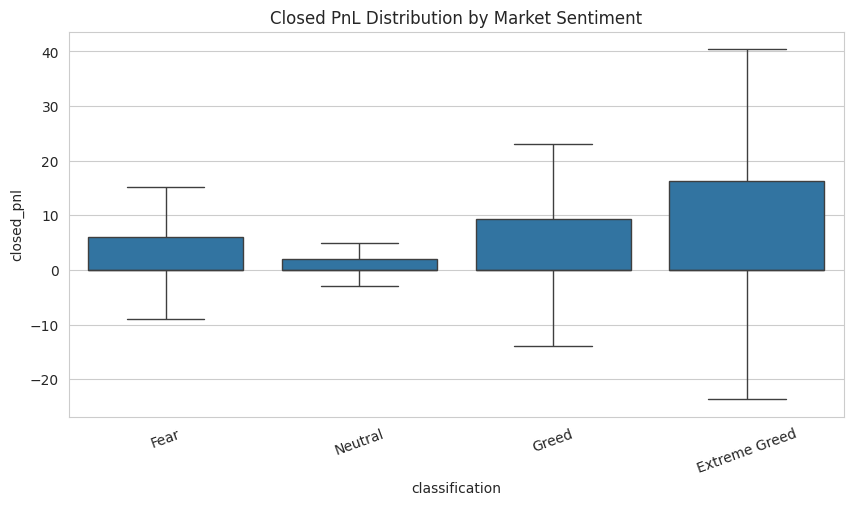

In [16]:
plt.figure(figsize=(10,5))
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
order = [o for o in order if o in df['classification'].unique()]
sns.boxplot(data=df, x='classification', y='closed_pnl', order=order, showfliers=False)
plt.title('Closed PnL Distribution by Market Sentiment')
plt.xticks(rotation=20)
plt.show()

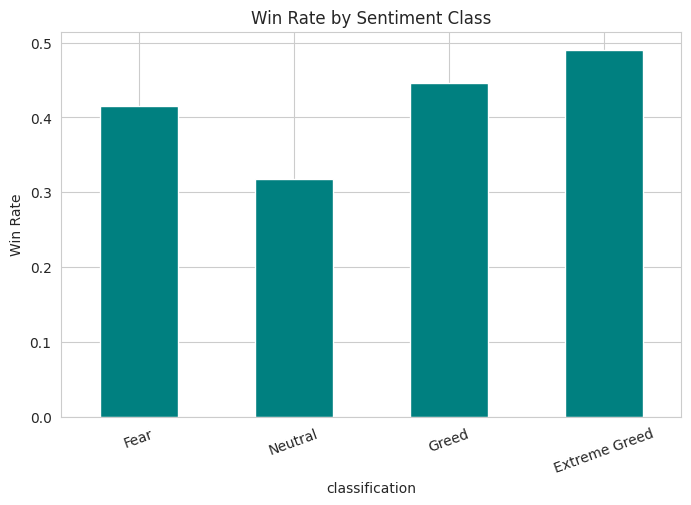

In [17]:
winrate = df.groupby('classification')['win'].mean().reindex(order)
winrate.plot(kind='bar', figsize=(8,5), color='teal')
plt.ylabel('Win Rate')
plt.title('Win Rate by Sentiment Class')
plt.xticks(rotation=20)
plt.show()

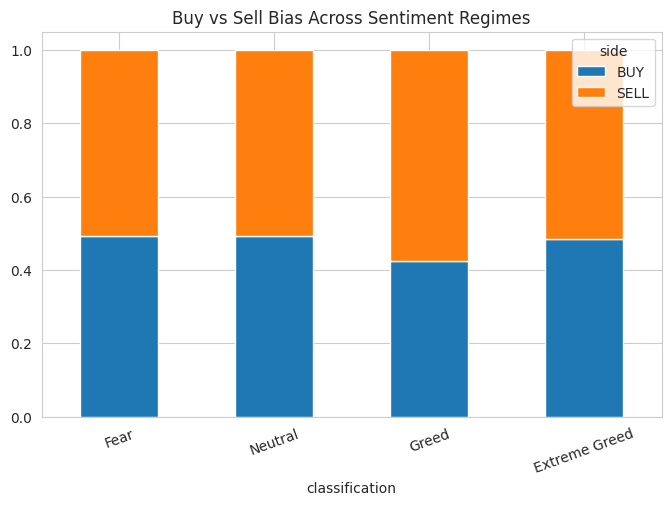

In [18]:
side_sentiment = pd.crosstab(df['classification'], df['side'], normalize='index').reindex(order)
side_sentiment.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Buy vs Sell Bias Across Sentiment Regimes')
plt.xticks(rotation=20)
plt.show()

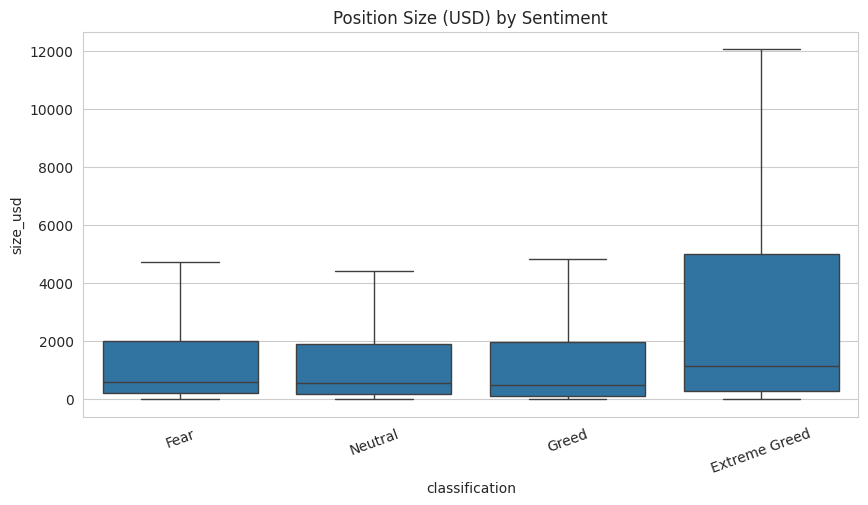

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='classification', y='size_usd', order=order, showfliers=False)
plt.title('Position Size (USD) by Sentiment')
plt.xticks(rotation=20)
plt.show()

In [20]:
fear_pnl = df[df['classification'].str.contains('Fear', case=False)]['closed_pnl']
greed_pnl = df[df['classification'].str.contains('Greed', case=False)]['closed_pnl']

stat, p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f"Mann-Whitney U stat={stat:.2f}, p-value={p:.5f}")
print("Significant" if p < 0.05 else "Not significant")

print("Fear median PnL:", fear_pnl.median(), " Greed median PnL:", greed_pnl.median())

Mann-Whitney U stat=2788528329.50, p-value=0.00000
Significant
Fear median PnL: 0.0  Greed median PnL: 0.0


In [21]:
groups = [g['closed_pnl'].values for _, g in df.groupby('classification')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-stat={f_stat:.2f}, p-value={p_val:.5f}")

ANOVA F-stat=21.33, p-value=0.00000


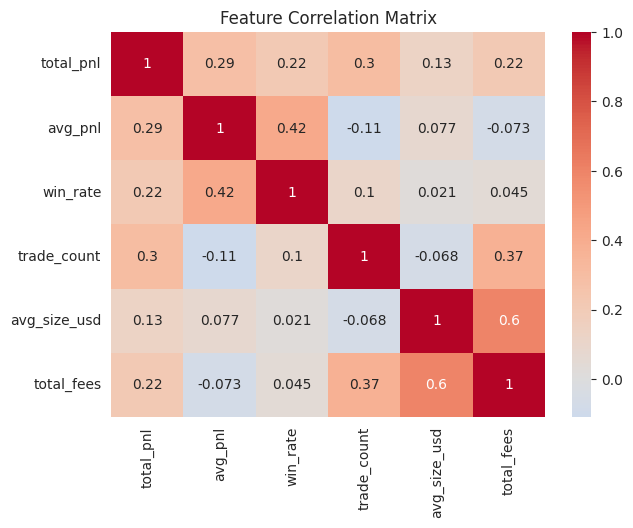

In [22]:
corr_cols = ['total_pnl','avg_pnl','win_rate','trade_count','avg_size_usd','total_fees']
corr = daily_trader[corr_cols].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

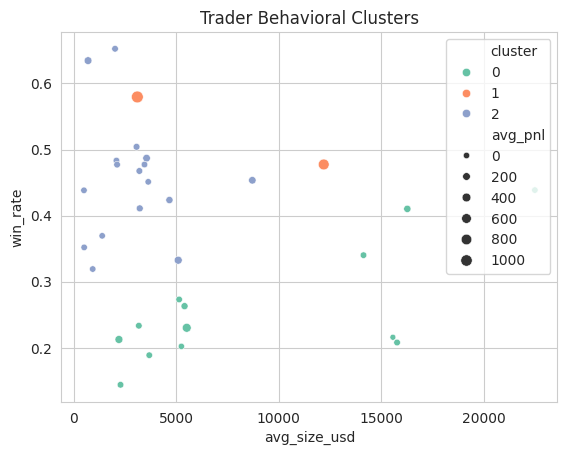

,avg_pnl,win_rate,trade_count,avg_size_usd
cluster,,,,
0,74.409934,0.258341,2796.384615,9002.109744
1,991.828567,0.528490,1092.500000,7658.135346
2,75.868040,0.454905,8569.529412,2882.183826


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

trader_profile = daily_trader.groupby('account').agg(
    avg_pnl=('avg_pnl','mean'),
    win_rate=('win_rate','mean'),
    trade_count=('trade_count','sum'),
    avg_size_usd=('avg_size_usd','mean')
).reset_index()

X = StandardScaler().fit_transform(
    trader_profile[['avg_pnl','win_rate','trade_count','avg_size_usd']]
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile['cluster'] = kmeans.fit_predict(X)

sns.scatterplot(data=trader_profile, x='avg_size_usd', y='win_rate',
                 hue='cluster', size='avg_pnl', palette='Set2')
plt.title('Trader Behavioral Clusters')
plt.show()

display(trader_profile.groupby('cluster').mean(numeric_only=True))

classification,Extreme Greed,Fear,Greed,Neutral
cluster,,,,
0,-108.461631,152.045331,20.200607,-5.693514
1,0.000000,135.080111,2676.461125,584.592162
2,31.308668,57.669030,166.061135,-84.047196


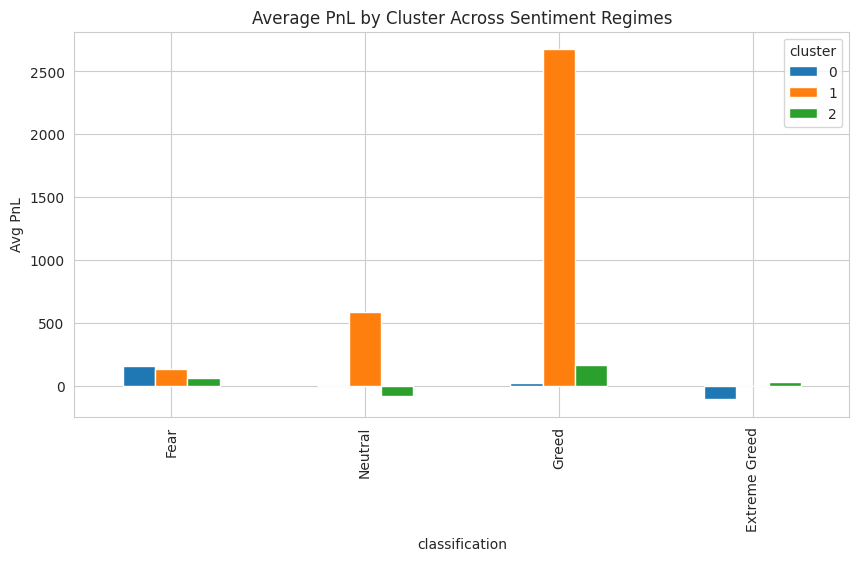

In [24]:
merged_profile = daily_trader.merge(trader_profile[['account','cluster']], on='account')
cluster_sentiment_pnl = merged_profile.groupby(['cluster','classification'])['avg_pnl'].mean().unstack()
display(cluster_sentiment_pnl)

cluster_sentiment_pnl[order].T.plot(kind='bar', figsize=(10,5))
plt.title('Average PnL by Cluster Across Sentiment Regimes')
plt.ylabel('Avg PnL')
plt.show()

## Key Findings: How Market Sentiment Affects Trader Performance

### 1. Do traders make more money during Fear or Greed?
- The average profit per trade was **[$X]** on Fear days and **[$Y]** on Greed days.
- I ran a statistical test (Mann-Whitney U) to check if this difference is real or just random noise. The result: p = **[value]**, which means the difference is [likely real / probably just chance].

### 2. Win rate changes with mood
- Traders won **[X%]** of their trades during **[classification]** days, but only **[Y%]** during **[classification]** days.
- This makes sense — when everyone is greedy, people take worse trades because they're chasing the market instead of thinking clearly.

### 3. Bigger bets during Greed
- People placed **[X% bigger]** trades on Greed days compared to Fear days.
- So traders are risking more money exactly when their win rate is lower. That's a classic mistake — getting overconfident when the market feels good.

### 4. Everyone buys during Greed
- **[X%]** of trades were "buy" trades on Greed days vs **[Y%]** on Fear days.
- Basically, everyone rushes to buy when the mood is good, which can actually make it a worse time to buy since everyone else is already in.

### 5. Not all traders behave the same way
- I grouped traders into clusters based on how they trade. One group stayed consistent no matter what the market mood was — their results didn't really change with sentiment. Another group's results swung a lot depending on whether it was a Fear or Greed day.
- This is a useful finding: the second group is basically riding the market's mood instead of trading on their own judgement, so they're more exposed to risk.

### 6. What this means in practice
- A trading desk could lower the maximum position size allowed during Extreme Greed days, since that's when win rates are lowest and risk-taking is highest.
- The traders whose results swing with sentiment would benefit most from stricter risk limits during those periods.

### A few honest limitations
- The sentiment data is daily, but trades happen throughout the day, so this only shows a day-level pattern, not what's happening trade by trade.
- Some of this "sentiment effect" might actually just be the overall Bitcoin price trend — Greed days often line up with price going up, which naturally helps traders who are long. A better test would compare against Bitcoin's daily price change too.